In [34]:
import pandas as pd
import matplotlib.pyplot as plt

In [35]:
uri = 'code_book_data_sci_ai_ml/data/sale_quarterly1.xlsx'
cols = 'b:e'
df = pd.read_excel(uri, sheet_name = 'Sheet1', usecols=cols , header =2 , dtype = {'Quarter':str})
df.head()
df.describe()

,Sales
count,20.000000
mean,570.500000
std,349.186649
min,50.000000
25%,287.500000
50%,600.000000
75%,900.000000
max,1000.000000


In [36]:
df.Quarter = df.Quarter.astype('category')
df.dtypes

Employee      object
Sales          int64
Quarter     category
Country       object
dtype: object

In [37]:
print(df.columns.tolist())

['Employee', 'Sales', 'Quarter', 'Country']


In [38]:
df.describe(include='all')

,Employee,Sales,Quarter,Country
count,20,20.000000,20,20
unique,5,NaN,4,4
top,ณิแนน,NaN,1,US
freq,4,NaN,5,6
mean,NaN,570.500000,NaN,NaN
std,NaN,349.186649,NaN,NaN
min,NaN,50.000000,NaN,NaN
25%,NaN,287.500000,NaN,NaN
50%,NaN,600.000000,NaN,NaN
75%,NaN,900.000000,NaN,NaN


In [39]:
pvt = df.pivot_table(index='Quarter', values='Sales') 
pvt = df.pivot_table(index='Quarter', values='Sales', margins=True) 
pvt

C:\Users\USER\AppData\Local\Temp\ipykernel_10120\2205705881.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pvt = df.pivot_table(index='Quarter', values='Sales')
C:\Users\USER\AppData\Local\Temp\ipykernel_10120\2205705881.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pvt = df.pivot_table(index='Quarter', values='Sales', margins=True)


,Sales
Quarter,
1,600.0
2,462.0
3,630.0
4,590.0
All,570.5


In [40]:
pvt = df.pivot_table(index=['Quarter'], values = ['Sales'] ,aggfunc=['sum','max','min','mean'], margins = True)
pvt

C:\Users\USER\AppData\Local\Temp\ipykernel_10120\2094270517.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pvt = df.pivot_table(index=['Quarter'], values = ['Sales'] ,aggfunc=['sum','max','min','mean'], margins = True)
C:\Users\USER\AppData\Local\Temp\ipykernel_10120\2094270517.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pvt = df.pivot_table(index=['Quarter'], values = ['Sales'] ,aggfunc=['sum','max','min','mean'], margins = True)
C:\Users\USER\AppData\Local\Temp\ipykernel_10120\2094270517.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to sil

,sum,max,min,mean
,Sales,Sales,Sales,Sales
Quarter,,,,
1,3000,1000,300,600.0
2,2310,1000,50,462.0
3,3150,1000,200,630.0
4,2950,1000,50,590.0
All,11410,1000,50,570.5


In [41]:
df['Import'] = df['Sales'] - 50
df.head()

,Employee,Sales,Quarter,Country,Import
0,ณิแนน,1000,1,US,950
1,กอบเกียรติ,300,1,ญี่ปุ่น,250
2,Tina,400,1,ไทย,350
3,Maria,500,1,UK,450
4,Bill,800,1,US,750


In [42]:
pvt = df.pivot_table(index=['Quarter'],values=['Import','Sales'], aggfunc = {'Sales':'sum','Import':'mean'} , margins=True)
pvt

C:\Users\USER\AppData\Local\Temp\ipykernel_10120\760281769.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pvt = df.pivot_table(index=['Quarter'],values=['Import','Sales'], aggfunc = {'Sales':'sum','Import':'mean'} , margins=True)


,Import,Sales
Quarter,,
1,550.0,3000
2,412.0,2310
3,580.0,3150
4,540.0,2950
All,520.5,11410


In [43]:
pvt = df.pivot_table(index=['Quarter'], values='Sales', aggfunc='sum')
pvt = pvt.applymap("{0:,}".format)

pvt = pvt.sort_values('Sales', ascending=False)
pvt

C:\Users\USER\AppData\Local\Temp\ipykernel_10120\1476034105.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pvt = df.pivot_table(index=['Quarter'], values='Sales', aggfunc='sum')
C:\Users\USER\AppData\Local\Temp\ipykernel_10120\1476034105.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  pvt = pvt.applymap("{0:,}".format)


,Sales
Quarter,
3,"3,150"
1,"3,000"
4,"2,950"
2,"2,310"


C:\Users\USER\AppData\Local\Temp\ipykernel_10120\2588048672.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pvt = df.pivot_table(index=['Quarter'], values='Sales', aggfunc='sum')


<Axes: xlabel='Quarter'>

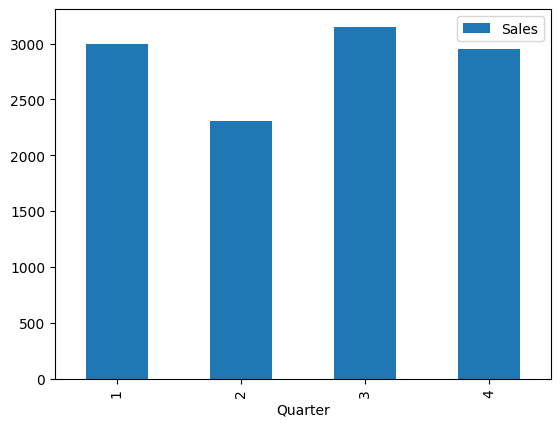

In [44]:
pvt = df.pivot_table(index=['Quarter'], values='Sales', aggfunc='sum')
pvt.plot.bar()

<Axes: xlabel='Quarter'>

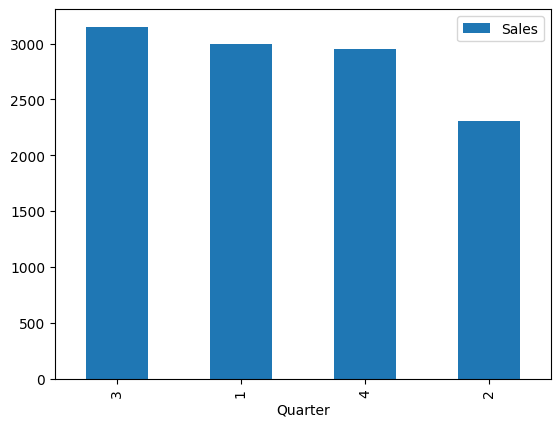

In [45]:
pvt_sorted = pvt.sort_values('Sales' , ascending=False)
pvt_sorted.plot.bar()

,Sales
Country,
UK,1450
US,2960
ญี่ปุ่น,3600
ไทย,3400


C:\Users\USER\AppData\Roaming\Python\Python314\site-packages\IPython\core\events.py:82: UserWarning: Glyph 3597 (\N{THAI CHARACTER YO YING}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\USER\AppData\Roaming\Python\Python314\site-packages\IPython\core\events.py:82: UserWarning: Glyph 3637 (\N{THAI CHARACTER SARA II}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\USER\AppData\Roaming\Python\Python314\site-packages\IPython\core\events.py:82: UserWarning: Glyph 3656 (\N{THAI CHARACTER MAI EK}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\USER\AppData\Roaming\Python\Python314\site-packages\IPython\core\events.py:82: UserWarning: Glyph 3611 (\N{THAI CHARACTER PO PLA}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\USER\AppData\Roaming\Python\Python314\site-packages\IPython\core\events.py:82: UserWarning: Glyph 3640 (\N{THAI CHARACTER SARA U}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users

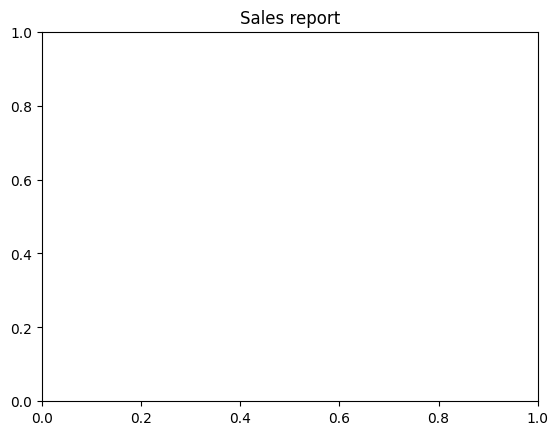

C:\Users\USER\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3597 (\N{THAI CHARACTER YO YING}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3637 (\N{THAI CHARACTER SARA II}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3656 (\N{THAI CHARACTER MAI EK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3611 (\N{THAI CHARACTER PO PLA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 36

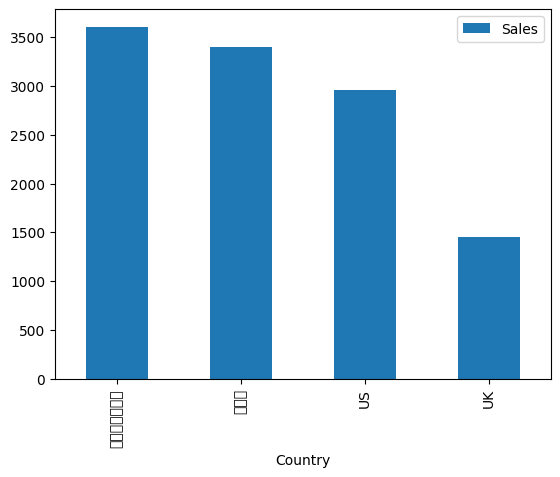

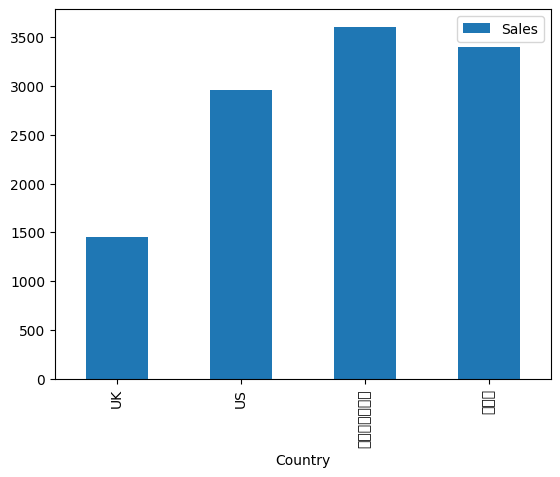

In [46]:
pvt = df.pivot_table(index=['Country'], values=['Sales'],aggfunc='sum')
plt.title("Sales report")
pvt.sort_values(['Sales'] , ascending= False).plot.bar()
pvt.plot.bar()
pvt

C:\Users\USER\AppData\Local\Temp\ipykernel_10120\283565134.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pvt = df.pivot_table(index=['Country','Quarter'] , values='Sales', aggfunc='sum')


<Axes: ylabel='Country,Quarter'>

C:\Users\USER\AppData\Roaming\Python\Python314\site-packages\IPython\core\events.py:82: UserWarning: Glyph 3597 (\N{THAI CHARACTER YO YING}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\USER\AppData\Roaming\Python\Python314\site-packages\IPython\core\events.py:82: UserWarning: Glyph 3637 (\N{THAI CHARACTER SARA II}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\USER\AppData\Roaming\Python\Python314\site-packages\IPython\core\events.py:82: UserWarning: Glyph 3656 (\N{THAI CHARACTER MAI EK}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\USER\AppData\Roaming\Python\Python314\site-packages\IPython\core\events.py:82: UserWarning: Glyph 3611 (\N{THAI CHARACTER PO PLA}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\USER\AppData\Roaming\Python\Python314\site-packages\IPython\core\events.py:82: UserWarning: Glyph 3640 (\N{THAI CHARACTER SARA U}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users

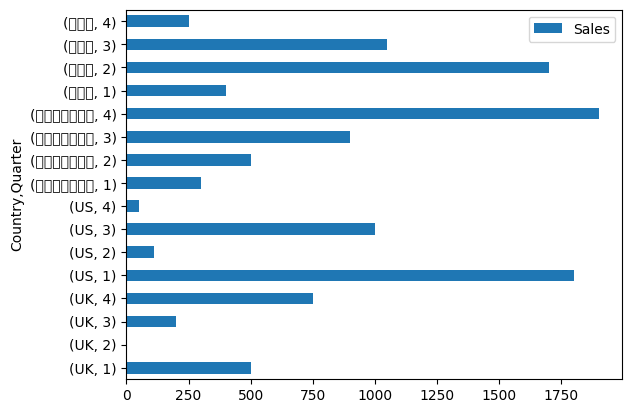

In [48]:
pvt = df.pivot_table(index=['Country','Quarter'] , values='Sales', aggfunc='sum')
pvt.plot.barh()